In [1]:

import numpy as np
import healpy as hp
from matplotlib import pyplot as plt

import pymaster as nmt
import sys
sys.path.append('../')
from scripts.true_cmb import true_cmb
from scripts.compute_decoupled_cl import compute_decoupled_cl
from scripts.cosine_smoothed_mask import cosine_smoothed_mask
from scripts.apply_HILC import apply_HILC
from scripts.compute_weights import compute_weights
from scripts.compute_alm_ilc import compute_alm_ilc
from scripts.mask_maps import mask_maps

In [2]:
nside=128
npix=hp.nside2npix(nside)
nsims=10
lmax=3*nside -1 
almsize=hp.Alm.getsize(lmax)
ells =np.arange(lmax+1)
print(ells.shape)
norm= (ells*(ells+1))/(2*np.pi)

(384,)


In [3]:
mask= cosine_smoothed_mask(nside)
mask= (mask*(-1))+1

In [4]:
cmb_th=true_cmb()/norm[2:]

/home/iloveorcas/Internship_Rome/tests/../scripts/true_cmb.py:11: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=382`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  cl_th = np.loadtxt("https://portal.nersc.gov/project/cmb/pysm-data/pysm_2/camb_lenspotentialCls.dat", max_rows=382 ,usecols=(1)) #skiprows=0,


In [5]:
print(cmb_th.shape)

(382,)


In [6]:
def gen_raw_cmb(cl,nsims,nside):
    """Gnere

    Args:
        cl (_type_): _description_
        nsims (_type_): _description_
        nside (_type_): _description_

    Returns:
        _type_: _description_
    """
    cmb_raw=[]
    cl_raw=[]
    npix = hp.nside2npix(nside)
    
    for i in range(nsims):
        np.random.seed(i)
        cl_raw.append(hp.alm2cl(hp.synalm(cl, lmax=383)))
        alm=hp.synalm(cl)
        cmb_raw.append(hp.alm2map(alm, nside))
        
    cmb_raw = np.array(cmb_raw)
    cl_raw = np.array(cl_raw)
    cl_raw = cl_raw[:, 2:]  # Keep only the elements starting from index 2
    """cmb_raw=np.tile(cmb_raw, (1, 7))
    cmb_raw = cmb_raw.reshape(nsims, 7, npix)"""
    return cmb_raw, cl_raw

In [7]:
map, cls=gen_raw_cmb(cmb_th, nsims, nside)
print(cls.shape)
print(map.shape)

(10, 382)
(10, 196608)


In [8]:
map=np.tile(map, (1, 7))
map = map.reshape(nsims,7, npix)
print(map.shape)

(10, 7, 196608)


In [71]:
def compute_decoupled_cl_2( maps: np.ndarray, masks:np.ndarray, X:bool, nsides:int, l_max:int, n_freq:int)-> np.ndarray:
    """
    Compute the power spectra using NaMaster for a set of frequency maps.

    Parameters:
    - maps: numpy array of shape (n_freqs, n_maps) containing the frequency maps
    - masks: mask to apply to the maps
    - X: flag to indicate if the input maps are masked
    - nsides: resolution parameter for the maps
    - l_max: maximum multipole for the power spectra
    - n_freq: number of frequency channels

    Returns:
    - p_cl: raw power spectrum (coupled)
    - matrix: mode coupling matrix
    - cldec: decoupled power spectrum
    """
    p_cl =np.zeros((l_max+1, n_freq, n_freq))
    cldec = np.zeros((l_max+1, n_freq, n_freq))
    

    # Loop over all pairs of frequency maps (cross-power spectra)
    for i in range(n_freq):
        for j in range(i, n_freq):  # Compute only upper triangle (symmetric matrix)
            
            # Define the masked fields for the two maps
            f_i = nmt.NmtField(1 - masks, [maps[i, :]], masked_on_input=X, lmax=381) 
            f_j = nmt.NmtField(1 - masks, [maps[j, :]], masked_on_input=X, lmax=381) 
            
            if X==True:
                p_cl[:,i,j]= hp.anafast(maps[i,:], maps[j,:], lmax=381)
            else:
                
                # Compute the coupled power spectrum for (i, j)
                masked_map_i= (1-masks)*maps[i, :]
                masked_map_j= (1-masks)*maps[j,:]
                p_cl[:,i,j]= hp.anafast(masked_map_i, masked_map_j, lmax=381)
            
            # p_cl[:, i, j] = nmt.compute_coupled_cell(f_i, f_j)
            


            # Define a NaMaster binning scheme (no binning)
            b = nmt.NmtBin.from_lmax_linear(381, 1)

            # Create NaMaster workspace and get the coupling matrix
            w = nmt.NmtWorkspace.from_fields(f_i, f_j, b)
            #w = nmt.NmtWorkspace()
            w.compute_coupling_matrix(f_i, f_j, b)
        
            #w.compute(f_i, f_j, b)
            matrix = w.get_coupling_matrix() #lxl

            # Compute the inverse of the mode-coupling matrix
            matrix_inv = np.linalg.pinv(matrix, rcond=1e-6)

            # Compute the decoupled power spectrum using Einstein summation
            cldec[:, i, j] = np.einsum('ij,j->i', matrix_inv, p_cl[:, i, j])

            # Since Cl is symmetric, copy the value to (j, i)
            if i != j:
                cldec[:, j, i] = cldec[:, i, j]
                p_cl[:, j, i] = p_cl[:, i, j]
    return cldec

In [72]:
alm_size=hp.Alm.getsize(381)
mask = cosine_smoothed_mask(nside)
mask= (mask*(-1))+1
cl_dec=compute_decoupled_cl_2(map[0,:,:], mask,False, nside, 381, 7)
# cl_dec=w.decouple_cell(pcl)
_, weights = compute_weights(7, 381, cl_dec)
_, alm_masked= mask_maps(map[0,:,:], mask, alm_size,381, 7, npix)
alm_ilc=compute_alm_ilc(alm_masked, alm_size, weights, 381)
clean_maps = hp.alm2map(alm_ilc, nside, 381, mmax=None)
clean_maps=np.tile(clean_maps, (1, 7))
clean_maps = clean_maps.reshape(7, npix)
cl_out=compute_decoupled_cl_2(clean_maps, mask,True, nside, 381, 7)

In [ ]:
# clean_maps = apply_HILC(map[0,:,:], lmax)

In [73]:
print(clean_maps.shape)
print(cl_out.shape)
print(cl_dec.shape)

(7, 196608)
(382, 7, 7)
(382, 7, 7)


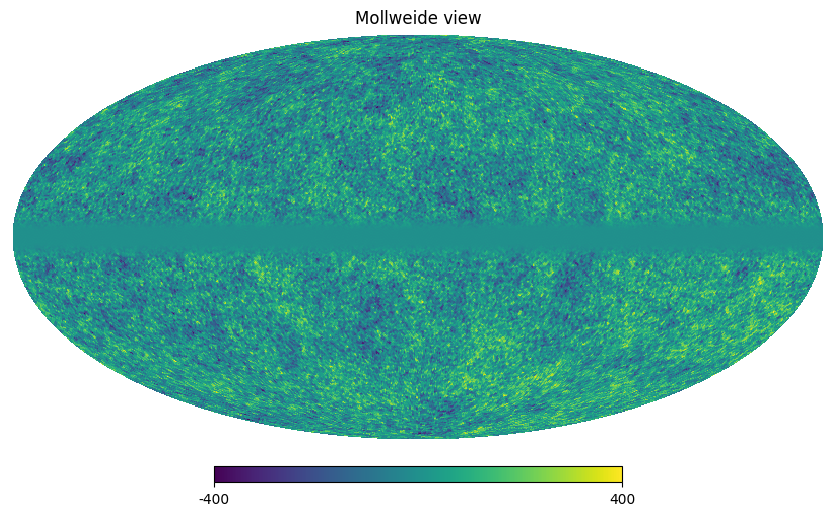

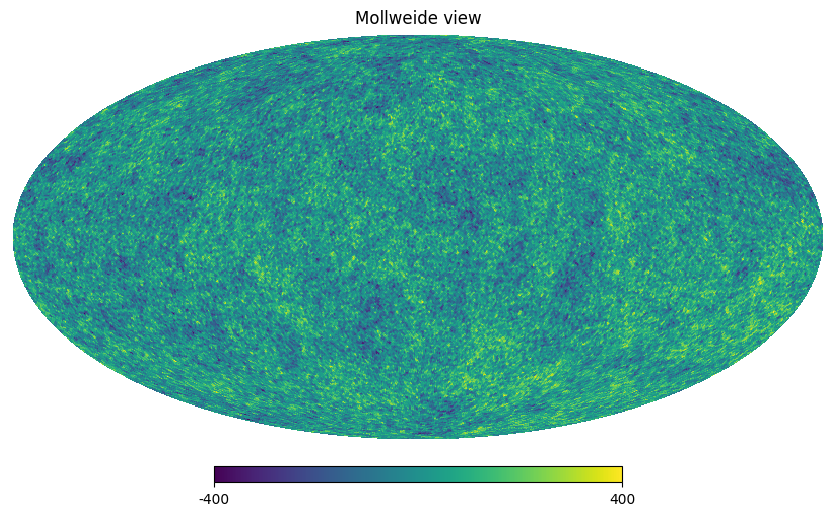

In [50]:
hp.mollview(clean_maps[0,:], min=-400, max=400)
hp.mollview(map[0,0,:], min=-400, max=400)

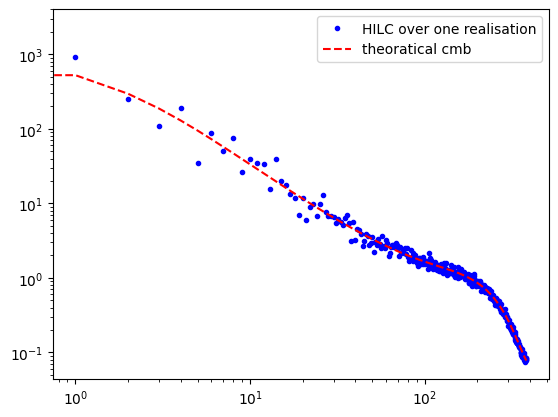

In [83]:
plt.plot(cl_out[:,0,0], 'b.',label="HILC over one realisation")
# plt.plot(cl_dec[:381,0,0], 'k.',label="Decoupled CMB")
# plt.plot(hp.anafast(map[0,0,:], lmax=381), label="Input map")
plt.plot(cmb_th,'r--',label="theoratical cmb")
plt.legend()
# plt.ylim(1e-2,10)
plt.xscale('log')
plt.yscale('log')

In [37]:
print(cl_out.shape)
print(cl_dec.shape)

(382, 7, 7)
(382, 7, 7)


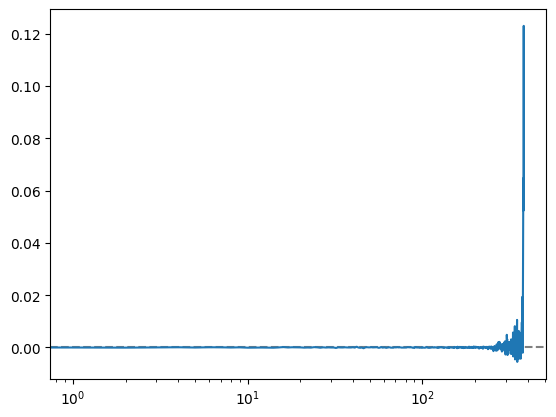

In [35]:
bias=(cl_out[:,0,0]-cl_dec[:,0,0])/cl_dec[:,0,0]
plt.axhline(0, linestyle="--", color="gray")
plt.plot(bias)
plt.xscale('log')


Text(0.5, 1.0, 'Bias in single realisation')

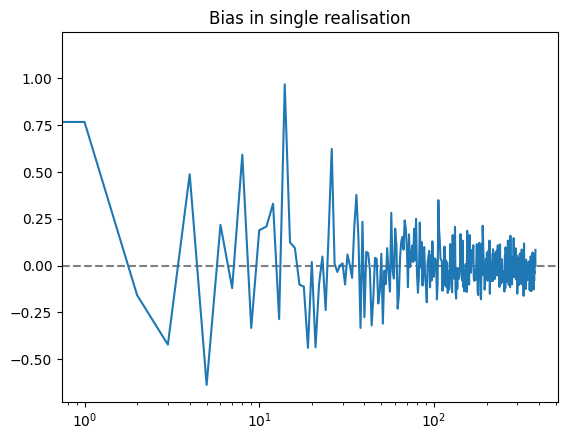

In [85]:
bias_hilc=(cl_out[:,0,0]-cmb_th)/cmb_th
# plt.plot(-3/(2*ells[2:]+1), label="Expected Bias", color="red")
plt.axhline(0, linestyle="--", color="gray")
plt.plot(bias_hilc)
plt.xscale('log')
plt.title("Bias in single realisation")
